In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import re
import requests

from PIL import Image
from io import BytesIO
from IPython.display import Audio, Video, display

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [3]:
# Read CSV file

csv_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

iris_df = pd.read_csv(csv_url)

print("First five rows of the CSV dataset:")
display(iris_df.head())

print("\nCSV File Properties")
print("-------------------")
print("Shape:", iris_df.shape)
print("Dimensions:", iris_df.ndim)
print("Number of elements:", iris_df.size)
print("Number of rows:", len(iris_df))
print("Columns:", list(iris_df.columns))

First five rows of the CSV dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



CSV File Properties
-------------------
Shape: (150, 5)
Dimensions: 2
Number of elements: 750
Number of rows: 150
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


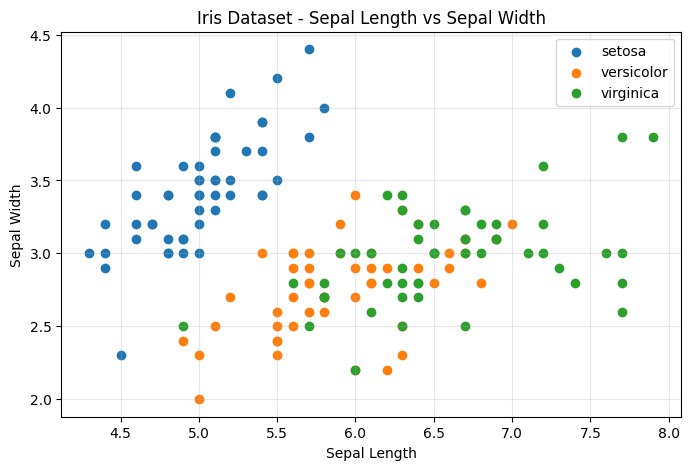

In [4]:
# Scatter plot of Iris dataset

plt.figure(figsize=(8, 5))

for species in iris_df["species"].unique():
    data = iris_df[iris_df["species"] == species]
    
    plt.scatter(
        data["sepal_length"],
        data["sepal_width"],
        label=species
    )

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset - Sepal Length vs Sepal Width")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [5]:
# Create an XLSX file from the Iris dataset

excel_file = "iris_dataset.xlsx"

iris_df.to_excel(excel_file, index=False)

# Read the XLSX file

excel_df = pd.read_excel(excel_file)

print("First five rows of the XLSX dataset:")
display(excel_df.head())

print("\nXLSX File Properties")
print("--------------------")
print("Shape:", excel_df.shape)
print("Dimensions:", excel_df.ndim)
print("Number of elements:", excel_df.size)
print("Number of rows:", len(excel_df))
print("Columns:", list(excel_df.columns))

First five rows of the XLSX dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



XLSX File Properties
--------------------
Shape: (150, 5)
Dimensions: 2
Number of elements: 750
Number of rows: 150
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


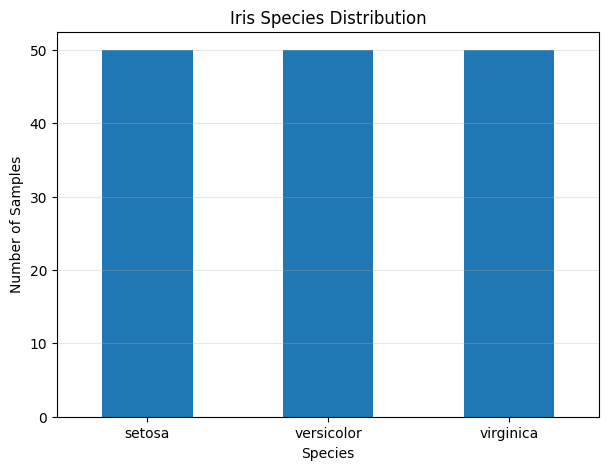

In [6]:
# Bar chart showing species distribution

species_counts = excel_df["species"].value_counts()

plt.figure(figsize=(7, 5))

species_counts.plot(kind="bar")

plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.title("Iris Species Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [7]:
# Read JSON data

json_url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(json_url)

json_data = response.json()

# Convert JSON data into a DataFrame

json_df = pd.json_normalize(json_data)

print("First five rows of the JSON dataset:")
display(json_df.head())

print("\nJSON File Properties")
print("--------------------")
print("Shape:", json_df.shape)
print("Dimensions:", json_df.ndim)
print("Number of elements:", json_df.size)
print("Number of rows:", len(json_df))
print("Columns:", list(json_df.columns))

First five rows of the JSON dataset:


,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems



JSON File Properties
--------------------
Shape: (10, 15)
Dimensions: 2
Number of elements: 150
Number of rows: 10
Columns: ['id', 'name', 'username', 'email', 'phone', 'website', 'address.street', 'address.suite', 'address.city', 'address.zipcode', 'address.geo.lat', 'address.geo.lng', 'company.name', 'company.catchPhrase', 'company.bs']


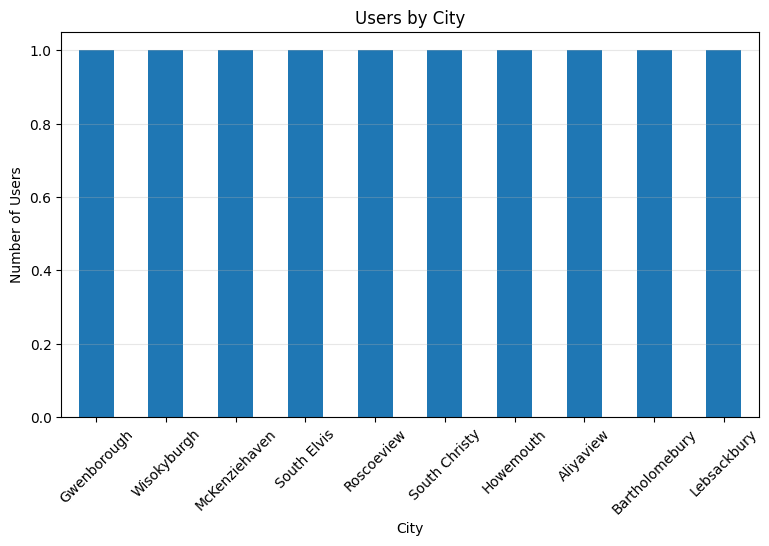

In [8]:
# Extract city names from JSON data

cities = [user["address"]["city"] for user in json_data]

city_counts = pd.Series(cities).value_counts()

plt.figure(figsize=(9, 5))

city_counts.plot(kind="bar")

plt.xlabel("City")
plt.ylabel("Number of Users")
plt.title("Users by City")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

Image Properties
----------------
Image Type: <class 'numpy.ndarray'>
Dimensions: 3
Shape: (512, 512, 3)
Height: 512
Width: 512
Channels: 3


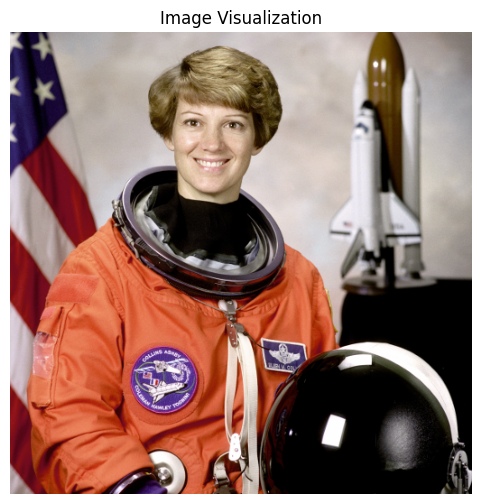

In [9]:
# Image Data Format

from skimage import data

# Load sample image
image = data.astronaut()

print("Image Properties")
print("----------------")
print("Image Type:", type(image))
print("Dimensions:", image.ndim)
print("Shape:", image.shape)
print("Height:", image.shape[0])
print("Width:", image.shape[1])
print("Channels:", image.shape[2])

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Image Visualization")
plt.show()

In [10]:
# Audio Data Format

import numpy as np
from scipy.io.wavfile import write
from IPython.display import Audio

# Audio parameters
sample_rate = 44100
duration = 3
frequency = 440

# Generate audio signal
t = np.linspace(
    0,
    duration,
    int(sample_rate * duration),
    endpoint=False
)

audio_signal = 0.5 * np.sin(2 * np.pi * frequency * t)

# Convert to 16-bit audio
audio_signal = np.int16(audio_signal * 32767)

# Save as WAV file
audio_file = "sample_audio.wav"
write(audio_file, sample_rate, audio_signal)

# Display properties
print("Audio File Properties")
print("---------------------")
print("File name:", audio_file)
print("Format: WAV")
print("Sample rate:", sample_rate, "Hz")
print("Duration:", duration, "seconds")
print("Frequency:", frequency, "Hz")

# Play audio
Audio(audio_file)

Audio File Properties
---------------------
File name: sample_audio.wav
Format: WAV
Sample rate: 44100 Hz
Duration: 3 seconds
Frequency: 440 Hz


In [11]:
# Video Data Format

import cv2
from IPython.display import Video

# Create a simple sample video locally
video_file = "sample_video.mp4"

width, height = 640, 360
fps = 30
duration = 3

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video_writer = cv2.VideoWriter(
    video_file,
    fourcc,
    fps,
    (width, height)
)

for i in range(fps * duration):

    frame = np.ones((height, width, 3), dtype=np.uint8) * 255

    # Moving circle
    x = int((width - 100) * i / (fps * duration - 1)) + 50
    y = height // 2

    cv2.circle(frame, (x, y), 40, (0, 0, 0), -1)

    # Add text
    cv2.putText(
        frame,
        "NLP Lab - Video",
        (170, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 0),
        2
    )

    video_writer.write(frame)

video_writer.release()

print("Video File Properties")
print("--------------------")
print("File name:", video_file)
print("Format: MP4")
print("Resolution:", width, "x", height)
print("FPS:", fps)
print("Duration:", duration, "seconds")

# Display video
Video(video_file, embed=True, width=640, height=360)

Video File Properties
--------------------
File name: sample_video.mp4
Format: MP4
Resolution: 640 x 360
FPS: 30
Duration: 3 seconds


In [12]:
# Create a text file

text_content = """
Natural Language Processing is a field of Artificial Intelligence.
NLP allows computers to understand, process and analyze human language.
Text preprocessing is an important step in NLP.
Tokenization, stemming and lemmatization are common NLP techniques.
"""

text_file = "nlp_sample.txt"

with open(text_file, "w", encoding="utf-8") as file:
    file.write(text_content)

# Read the text file

with open(text_file, "r", encoding="utf-8") as file:
    text = file.read()

print("Text File Content")
print("------------------")
print(text)

print("Text File Properties")
print("--------------------")
print("File size:", os.path.getsize(text_file), "bytes")
print("Number of characters:", len(text))
print("Number of words:", len(text.split()))
print("Number of lines:", len(text.splitlines()))

Text File Content
------------------

Natural Language Processing is a field of Artificial Intelligence.
NLP allows computers to understand, process and analyze human language.
Text preprocessing is an important step in NLP.
Tokenization, stemming and lemmatization are common NLP techniques.

Text File Properties
--------------------
File size: 256 bytes
Number of characters: 256
Number of words: 35
Number of lines: 5


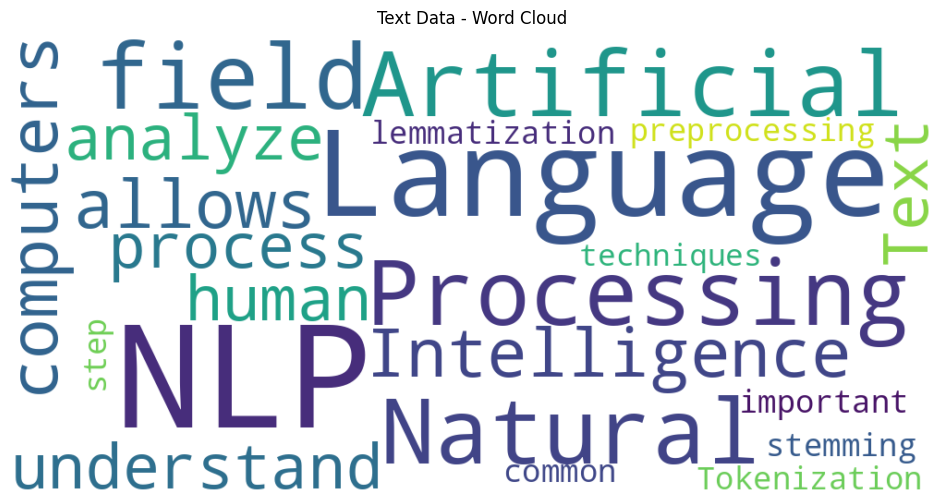

In [13]:
# Generate a word cloud

from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Text Data - Word Cloud")

plt.show()